# Test de la classe ``TimeScheme``


On résout simplement le problème aux conditions initiales suivant
$$
\begin{aligned}
\frac{\mathrm{d} x(t)}{\mathrm{d}t} +x(t) = 0\\
x(0) = 1
\end{aligned}
$$
Qui a pour solution (attention, c'est difficile, c'est niveau L1)
$$
x(t) = e^{-t}
$$

Ce test repose sur la classe ``Params``, qui n'est (au 21 Juillet 2026) pas définitive.

A noter aussi, c'est normal que le schéma LeapFrog soit d'ordre 1, c'est dû au filtre d'Asselin, qui sert à éliminer les oscillations parasites.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent      # pyTQG
SRC = ROOT / "pyTQG_solver"

print(ROOT)
print(SRC)
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG
C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG\pyTQG_solver


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

Schémas implémentés ('Euler', 'LeapFrog', 'Heun', 'RK2', 'RK4')
0.13669542544552385


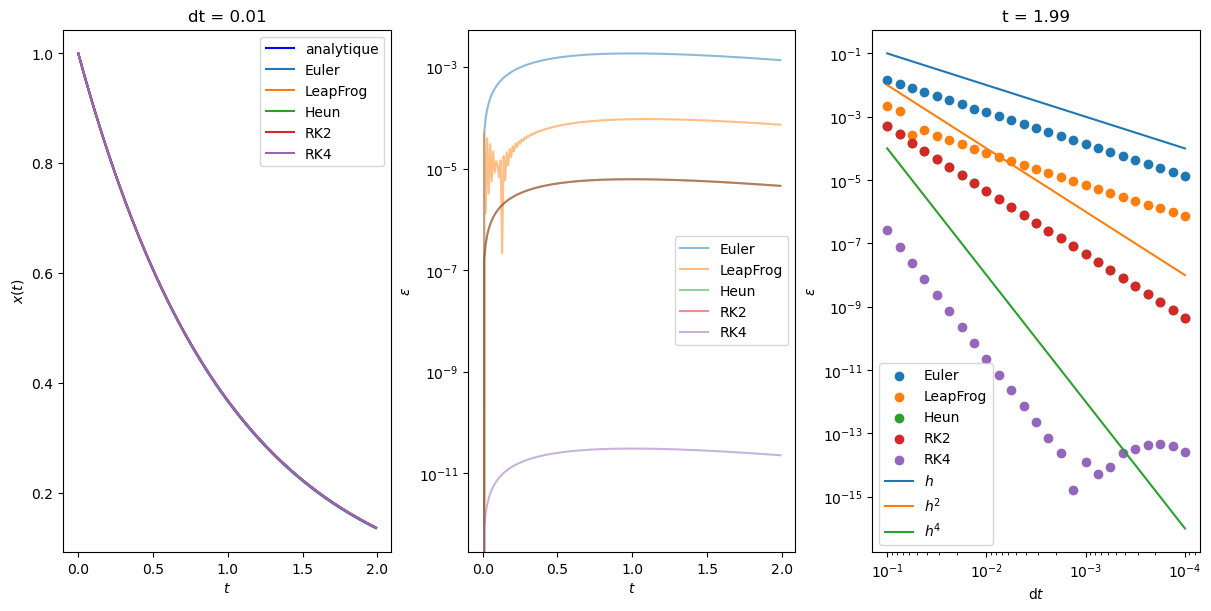

In [4]:
%autoreload 1
%aimport Params
%aimport TimeScheme

dt_ = 0.01
t_max = 2.0
N = int(t_max/dt_)

t = np.arange(0.0, t_max, dt_)

#Solution analytique
x_t = np.exp(-t)
x_ana = lambda T : np.exp(-T)

rhs = lambda z, t : -z
x0 = 1.0

#print(f"u_ana {x_t}")
#print(f"t = {t}")
params_test = Params.Params()
liste_Schemes = TimeScheme.TimeScheme(params_test, rhs, x0).get_Schemes()
print(f"Schémas implémentés {liste_Schemes}")

def loop(u0, RHS, Tmax = 2.0, dt = 0.01, scheme = 'Euler'):
    N_it_max = int(np.round(Tmax/dt))
    u = np.zeros(N_it_max)
    liste_t = np.zeros(N_it_max)
    t_ = 0.0
    u[0] = u0
    params = Params.Params()
    params.time_scheme = scheme
    TS = TimeScheme.TimeScheme(params, RHS, u0)

    for i in range(1, N_it_max):
        u[i] = TS.Step(dt)
        t_ += dt
        liste_t[i] = t_
    #del TS
    return u, liste_t

#fig = plt.figure()

#plt.plot(t, u_Euler, label = 'Euler')
#plt.plot(t, x_t, label = 'analytique')
#plt.xlabel("$t$")
#plt.ylabel("$x(t)$")
#plt.legend()

#fig = plt.figure()
#plt.plot(t, err_Euler)

#plt.xlabel(r"$t$")
#plt.ylabel(r"$\epsilon$")
#plt.yscale('log')

fig = plt.figure( figsize  = (12, 6), constrained_layout = True)
axs = fig.subplots(1, 3, squeeze = False)
axs[0, 0].plot(t, x_t, label = 'analytique', color = 'b')

for Scheme in liste_Schemes : 
    #print(f"test Schéma {Scheme}")
    u_S, t_S = loop(x0, rhs, dt=dt_, scheme = Scheme)
    #print(f"U_S {u_S}")
    #print(t_S)
    axs[0, 0].plot(t_S, u_S, label = Scheme)
    axs[0, 1].plot(t, np.abs( u_S - x_ana(t_S) ), label = Scheme, alpha = 0.5)

axs[0, 0].set_title(f"dt = {dt_}")
axs[0, 0].set_xlabel("$t$")
axs[0, 0].set_ylabel("$x(t)$")

axs[0, 0].legend()



#axs[0, 1].plot(t, err_Euler, label = 'Euler')
axs[0, 1].legend()
axs[0, 1].set_xlabel(r"$t$")
axs[0, 1].set_ylabel(r"$\epsilon$")
axs[0, 1].set_yscale('log')

N_dt = 25
liste_dt = np.geomspace(1.0e-4, 0.1, num = N_dt)
print(x_t[-1])

#x_ana = lambda zz : np.exp(-zz)

for Scheme in liste_Schemes :
    err_ts_scheme = np.zeros(N_dt)
    #print(f"Scheme = {Scheme}")
    for i in range(0, N_dt):
        #t_i = np.arange(0, t_max+liste_dt[i], liste_dt[i])
        xs, ts_i = loop(x0, rhs, dt=liste_dt[i], scheme = Scheme)
        err_ts_scheme[i] = np.abs(xs[-1] - x_ana(ts_i[-1]))
        #print(f"dt = {liste_dt[i]}")
        #print(f"us[-1] = {xs[-1]}")
        del xs
        
    axs[0, 2].scatter(liste_dt, err_ts_scheme, label = Scheme)

axs[0, 2].set_title(f"t = {t[-1]}")
axs[0, 2].set_xlabel(r"$\mathrm{d}t$")
axs[0, 2].set_ylabel(r"$\epsilon$")
axs[0, 2].set_xscale('log')
axs[0, 2].set_yscale('log')

axs[0, 2].plot(liste_dt, liste_dt, label = r"$h$")
axs[0, 2].plot(liste_dt, liste_dt**2, label = r"$h^2$")
axs[0, 2].plot(liste_dt, liste_dt**4, label = r"$h^4$")

axs[0, 2].legend()
axs[0, 2].xaxis.set_inverted(True)

# Implémentation indépendante de Euler et LF avec filtre d'Asselin

[1.         0.99       0.9801     0.970299   0.96059601 0.95099005
 0.94148015 0.93206535 0.92274469 0.91351725 0.90438208 0.89533825
 0.88638487 0.87752102 0.86874581 0.86005835 0.85145777 0.84294319
 0.83451376 0.82616862 0.81790694 0.80972787 0.80163059 0.79361428
 0.78567814 0.77782136 0.77004315 0.76234271 0.75471929 0.74717209
 0.73970037 0.73230337 0.72498034 0.71773053 0.71055323 0.70344769
 0.69641322 0.68944909 0.6825546  0.67572905 0.66897176 0.66228204
 0.65565922 0.64910263 0.6426116  0.63618549 0.62982363 0.62352539
 0.61729014 0.61111724 0.60500607 0.59895601 0.59296645 0.58703678
 0.58116641 0.57535475 0.5696012  0.56390519 0.55826614 0.55268348
 0.54715664 0.54168508 0.53626823 0.53090554 0.52559649 0.52034052
 0.51513712 0.50998575 0.50488589 0.49983703 0.49483866 0.48989027
 0.48499137 0.48014146 0.47534004 0.47058664 0.46588078 0.46122197
 0.45660975 0.45204365 0.44752321 0.44304798 0.4386175  0.43423133
 0.42988901 0.42559012 0.42133422 0.41712088 0.41294967 0.4088

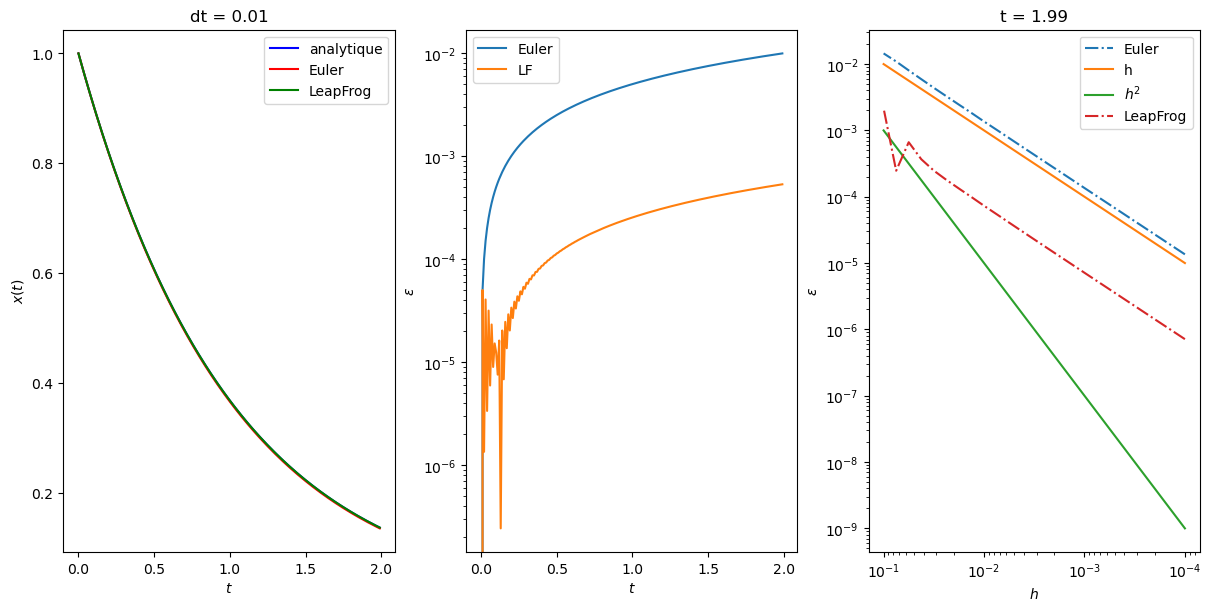

In [9]:
def Euler(x0,rhs_, dt = 0.01, tmax = 2.0):
    n = int(tmax/dt)
    x = x0
    tt=0.0
    x_liste = np.zeros(n)
    t_liste = np.zeros(n)
    x_liste[0] = x0
    for i in range(1, n):
        x+=dt*rhs_(x)
        x_liste[i] = x
        tt+=dt
        t_liste[i] = tt
    return x_liste, t_liste

def LeapFrog(x0,rhs_, dt = 0.01, tmax = 2.0, disp = False):
    n = int(tmax/dt)
    x_now = x0
    #print(f"x0 = {x0}")
    x_old = x0
    x_new = 0.0
    tt=0.0
    x_liste = np.zeros(n)
    t_liste = np.zeros(n)
    x_liste[0] = x0
    #Initialisation par Euler
    x_now  = x0 +dt*rhs_(x0)#x1
    x_f = x_now
    tt+=dt
    x_liste[1] = x_now
    t_liste[1] = tt
    if disp: 
        print("########################")
        print("Initialisation Euler")
        print(f"t = {tt}")
        print(f"x_old {x_old}")
        print(f"x_now {x_now}")
        print(f"x_new {x_new}")
        print("########################")

    for i in range(2, n):
        x_new = x_old + 2.0*dt*rhs_(x_now)
        x_now_f = x_now + 0.05 * (x_old + x_new - 2.0 * x_now)
        if disp: 
            print("########################")
            print(f"t = {tt}")
            print(f"x_old {x_old}")
            print(f"x_now {x_now}")
            print(f"x_new {x_new}")
            print("########################")
        x_old = x_now_f
        x_liste[i] = x_new
        x_now = x_new
        tt+=dt
        t_liste[i] = tt
    return x_liste, t_liste


N_dt = 25
liste_dt = np.geomspace(1.0e-4, 0.1, num = N_dt)
x0=1.0

fig = plt.figure( figsize  = (12, 6), constrained_layout = True)
axs = fig.subplots(1, 3, squeeze = False)

RHS2 = lambda x: -x

axs[0, 0].plot(t, x_t, label = 'analytique', color = 'b')

dt = 0.01
x_num, t_num = Euler(x0, RHS2, dt=dt)

x_LF, t_LF = LeapFrog(x0, RHS2, dt=dt, disp = False)

err_Euler = np.zeros(liste_dt.size)
err_LF = np.zeros(liste_dt.size)

print(x_num)
axs[0, 0].plot(t, x_num, label = 'Euler', color = 'r')
axs[0, 0].plot(t, x_LF, label = 'LeapFrog', color = 'g')
axs[0, 0].set_title(f"dt = {dt}")
axs[0, 0].set_xlabel("$t$")
axs[0, 0].set_ylabel("$x(t)$")
axs[0, 0].legend()



axs[0, 1].plot(t, np.abs(x_num - x_ana(t_num))/x_ana(t_num), label = 'Euler')
axs[0, 1].plot(t, np.abs(x_LF - x_ana(t_num))/x_ana(t_num), label = 'LF')
axs[0, 1].legend()
axs[0, 1].set_xlabel(r"$t$")
axs[0, 1].set_ylabel(r"$\epsilon$")
axs[0, 1].set_yscale('log')


for i in range(0, N_dt):
    xs, ts = Euler(x0, RHS2, dt=liste_dt[i])
    xs_LF, ts_LF = LeapFrog(x0, RHS2, dt=liste_dt[i])
    err_Euler[i] = np.abs(xs[-1] -x_ana(ts[-1]))
    err_LF[i] = np.abs(xs_LF[-1] -x_ana(ts_LF[-1]))
        
axs[0, 2].plot(liste_dt, err_Euler, label ='Euler', linestyle ='-.')
axs[0, 2].plot(liste_dt, 0.1*liste_dt, label = "h")
axs[0, 2].plot(liste_dt, 0.1*liste_dt**2, label = r"$h^2$")
axs[0, 2].plot(liste_dt, err_LF, label ='LeapFrog', linestyle ='-.')

axs[0, 2].set_title(f"t = {t[-1]}")
axs[0, 2].set_xlabel(r"$h$")
axs[0, 2].set_ylabel(r"$\epsilon$")
axs[0, 2].set_xscale('log')
axs[0, 2].set_yscale('log')
axs[0, 2].legend()
axs[0, 2].xaxis.set_inverted(True)

In [6]:
x_LF

array([1.        , 0.99      , 0.9802    , 0.971386  , 0.96175248,
       0.95312234, 0.94365179, 0.93520242, 0.92589139, 0.9176198 ,
       0.90846488, 0.90036812, 0.89136599, 0.88344117, 0.87458853,
       0.86683284, 0.85812646, 0.85053714, 0.84197384, 0.8345482 ,
       0.82612485, 0.81886025, 0.81057377, 0.80346764, 0.795315  ,
       0.78836481, 0.78034301, 0.77354631, 0.76565243, 0.75900681,
       0.75123795, 0.74474106, 0.73709436, 0.73074391, 0.72321658,
       0.71701032, 0.70959959, 0.70353534, 0.69623848, 0.69031411,
       0.68312844, 0.67734185, 0.67026473, 0.6646139 , 0.65764272,
       0.65212566, 0.64525785, 0.63987263, 0.63310565, 0.62785039,
       0.62118175, 0.6160546 , 0.60948184, 0.60448102, 0.5980017 ,
       0.59312547, 0.58673719, 0.58198385, 0.57568425, 0.57105215,
       0.5648389 , 0.56032642, 0.55419721, 0.5498028 , 0.54375535,
       0.5394775 , 0.53350955, 0.52934679, 0.52345613, 0.51940701,
       0.51359144, 0.50965459, 0.50391194, 0.500086  , 0.49441

In [7]:
x_num

array([1.        , 0.99      , 0.9801    , 0.970299  , 0.96059601,
       0.95099005, 0.94148015, 0.93206535, 0.92274469, 0.91351725,
       0.90438208, 0.89533825, 0.88638487, 0.87752102, 0.86874581,
       0.86005835, 0.85145777, 0.84294319, 0.83451376, 0.82616862,
       0.81790694, 0.80972787, 0.80163059, 0.79361428, 0.78567814,
       0.77782136, 0.77004315, 0.76234271, 0.75471929, 0.74717209,
       0.73970037, 0.73230337, 0.72498034, 0.71773053, 0.71055323,
       0.70344769, 0.69641322, 0.68944909, 0.6825546 , 0.67572905,
       0.66897176, 0.66228204, 0.65565922, 0.64910263, 0.6426116 ,
       0.63618549, 0.62982363, 0.62352539, 0.61729014, 0.61111724,
       0.60500607, 0.59895601, 0.59296645, 0.58703678, 0.58116641,
       0.57535475, 0.5696012 , 0.56390519, 0.55826614, 0.55268348,
       0.54715664, 0.54168508, 0.53626823, 0.53090554, 0.52559649,
       0.52034052, 0.51513712, 0.50998575, 0.50488589, 0.49983703,
       0.49483866, 0.48989027, 0.48499137, 0.48014146, 0.47534

In [8]:
XX = np.array([0, 1, 3])
f = lambda p : -p
print(f(XX))
print(XX)

[ 0 -1 -3]
[0 1 3]
